<a href="https://colab.research.google.com/github/randyliu078-bit/qss20-final-project/blob/main/code/03_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

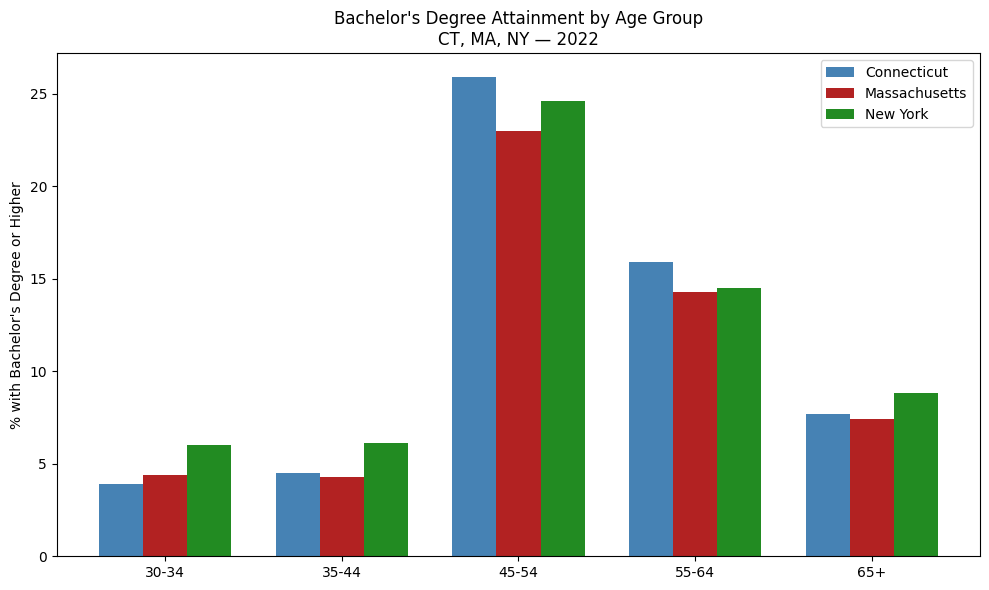

In [ ]:
# ============================================================
# 03_analysis.ipynb — QSS 20 Final Project — Randy Liu
# Visualizations and analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import requests
import io

API_KEY = "84be3d1f35c778150bb57bc7f815f88136459eac"

# ---- Re-pull ACS data ----
acs_url = "https://api.census.gov/data/2022/acs/acs1/subject?get=NAME,S1501_C02_006E,S1501_C02_007E,S1501_C02_008E,S1501_C02_009E,S1501_C02_010E,S1501_C02_011E&for=state:09,25,36&key=" + API_KEY
data = requests.get(acs_url).json()
acs_df = pd.DataFrame(data[1:], columns=data[0])
acs_df.columns = ["state_name","age_25_29","age_30_34","age_35_44","age_45_54","age_55_64","age_65plus","state_fips"]
acs_df = acs_df.replace("-888888888", None)
for col in ["age_30_34","age_35_44","age_45_54","age_55_64","age_65plus"]:
    acs_df[col] = pd.to_numeric(acs_df[col])

# ---- Figure 1: Bachelor's degree attainment by age group ----
age_groups = ["age_30_34","age_35_44","age_45_54","age_55_64","age_65plus"]
labels = ["30-34","35-44","45-54","55-64","65+"]
colors = {"Connecticut":"steelblue","Massachusetts":"firebrick","New York":"forestgreen"}

x = range(len(age_groups))
width = 0.25
fig, ax = plt.subplots(figsize=(10,6))

for i, (_, row) in enumerate(acs_df.iterrows()):
    vals = [pd.to_numeric(row[col]) for col in age_groups]
    ax.bar([xi + i*width for xi in x], vals, width, label=row["state_name"],
           color=list(colors.values())[i])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels)
ax.set_ylabel("% with Bachelor's Degree or Higher")
ax.set_title("Bachelor's Degree Attainment by Age Group\nCT, MA, NY — 2022")
ax.legend()
plt.tight_layout()
plt.savefig("fig1_degree_attainment.png", dpi=150)
plt.show()


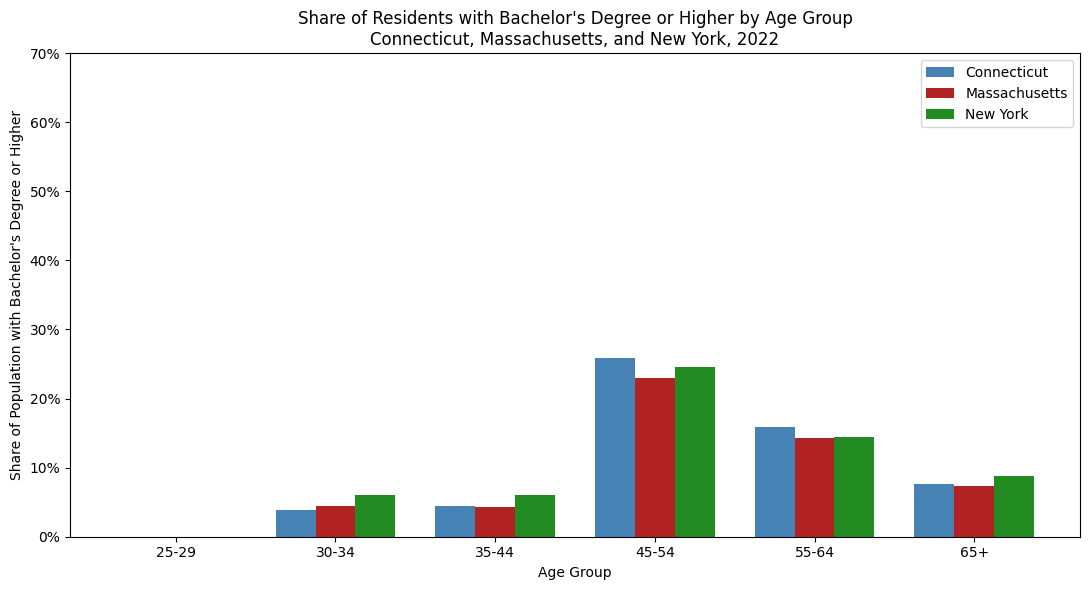

In [ ]:
# ---- Figure 1: Bachelor's degree attainment by age group (styled like Milestone 1) ----
age_groups = ["age_25_29","age_30_34","age_35_44","age_45_54","age_55_64","age_65plus"]
labels = ["25-29","30-34","35-44","45-54","55-64","65+"]

# Re-pull with age_25_29 included
data = requests.get(acs_url).json()
acs_df2 = pd.DataFrame(data[1:], columns=data[0])
acs_df2.columns = ["state_name","age_25_29","age_30_34","age_35_44","age_45_54","age_55_64","age_65plus","state_fips"]
for col in age_groups:
    acs_df2[col] = pd.to_numeric(acs_df2[col], errors="coerce")

fig, ax = plt.subplots(figsize=(11,6))
x = range(len(age_groups))
width = 0.25
colors = ["steelblue","firebrick","forestgreen"]

for i, (_, row) in enumerate(acs_df2.iterrows()):
    vals = [row[col] for col in age_groups]
    ax.bar([xi + i*width for xi in x], vals, width,
           label=row["state_name"], color=colors[i])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels)
ax.set_xlabel("Age Group")
ax.set_ylabel("Share of Population with Bachelor's Degree or Higher")
ax.set_title("Share of Residents with Bachelor's Degree or Higher by Age Group\nConnecticut, Massachusetts, and New York, 2022")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.legend(loc="upper right")
ax.set_ylim(0, 70)
plt.tight_layout()
plt.savefig("fig1_degree_attainment.png", dpi=150)
plt.show()


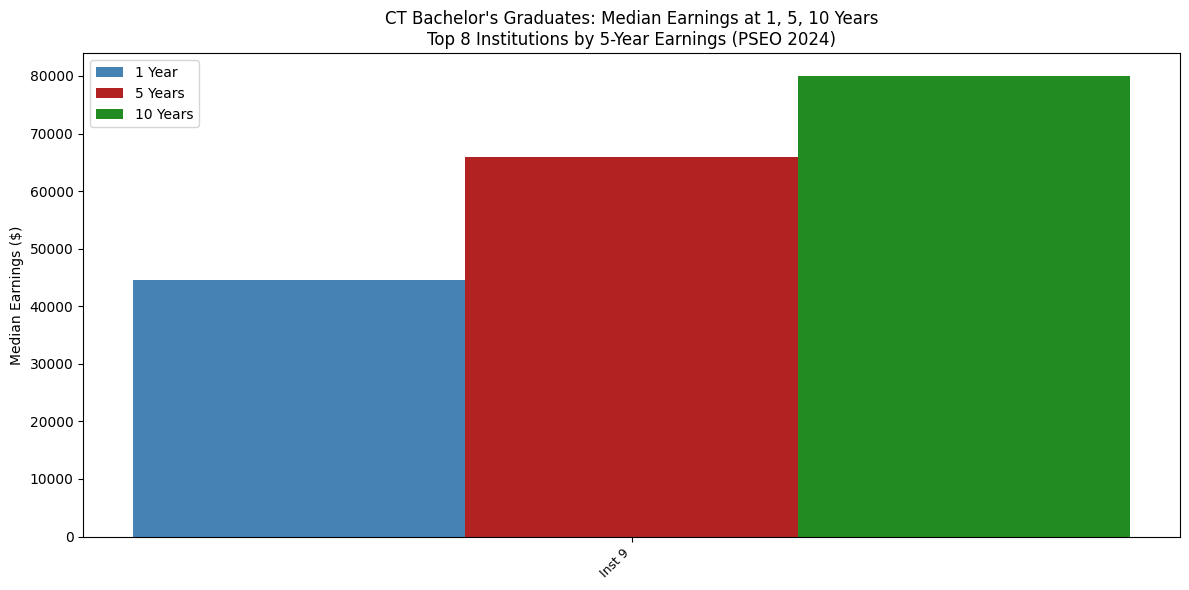

In [ ]:
# ---- Figure 2: PSEO median earnings at 1, 5, 10 years ----
pseo_df = pd.read_csv(io.BytesIO(requests.get(
    "https://lehd.ces.census.gov/data/pseo/R2024Q4/ct/pseoe_ct.csv.gz"
).content), compression="gzip", low_memory=False)

pseo_bach = pseo_df[
    (pseo_df["degree_level"] == 5) &
    (pseo_df["agg_level_pseo"] == 26) &
    (pseo_df["geo_level"] == "N") &
    (pseo_df["ind_level"] == "A")
].copy()

pseo_bach = pseo_bach.dropna(subset=["y1_p50_earnings","y5_p50_earnings","y10_p50_earnings"])
top = pseo_bach.nlargest(8, "y5_p50_earnings").reset_index(drop=True)

# Use institution code as label since names may be numeric
inst_labels = [f"Inst {row['institution']}" for _, row in top.iterrows()]

x = range(len(top))
width = 0.25
fig, ax = plt.subplots(figsize=(12,6))
ax.bar([i-0.25 for i in x], top["y1_p50_earnings"], width, label="1 Year", color="steelblue")
ax.bar([i      for i in x], top["y5_p50_earnings"],  width, label="5 Years", color="firebrick")
ax.bar([i+0.25 for i in x], top["y10_p50_earnings"], width, label="10 Years", color="forestgreen")

ax.set_xticks(list(x))
ax.set_xticklabels(inst_labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Median Earnings ($)")
ax.set_title("CT Bachelor's Graduates: Median Earnings at 1, 5, 10 Years\nTop 8 Institutions by 5-Year Earnings (PSEO 2024)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_pseo_earnings.png", dpi=150)
plt.show()


In [ ]:
# Diagnose what's in the filtered data
print("Rows after filter:", pseo_bach.shape[0])
print("Top rows:")
print(top[["institution","y1_p50_earnings","y5_p50_earnings","y10_p50_earnings"]])

Rows after filter: 1
Top rows:
   institution  y1_p50_earnings  y5_p50_earnings  y10_p50_earnings
0            9          44577.0          65860.0           79970.0


In [ ]:
# ---- Figure 2 fixed: loosen filter to get more institutions ----
pseo_bach2 = pseo_df[
    (pseo_df["degree_level"] == 5) &
    (pseo_df["geo_level"] == "N") &
    (pseo_df["ind_level"] == "A")
].copy()

pseo_bach2 = pseo_bach2.dropna(subset=["y1_p50_earnings","y5_p50_earnings","y10_p50_earnings"])
print("Rows after looser filter:", pseo_bach2.shape[0])
print(pseo_bach2[["institution","agg_level_pseo","y1_p50_earnings","y5_p50_earnings"]].head(10))


Rows after looser filter: 1828
    institution  agg_level_pseo  y1_p50_earnings  y5_p50_earnings
4             9              26          44577.0          65860.0
10            9              28          37773.0          64700.0
16            9              28          34381.0          58372.0
19            9              28          44584.0          66693.0
24            9              28          40492.0          53667.0
29            9              28          38815.0          60593.0
39            9              28          63131.0          88083.0
47            9              28          37905.0          61488.0
53            9              28          71880.0          93407.0
59            9              28          59651.0          82038.0


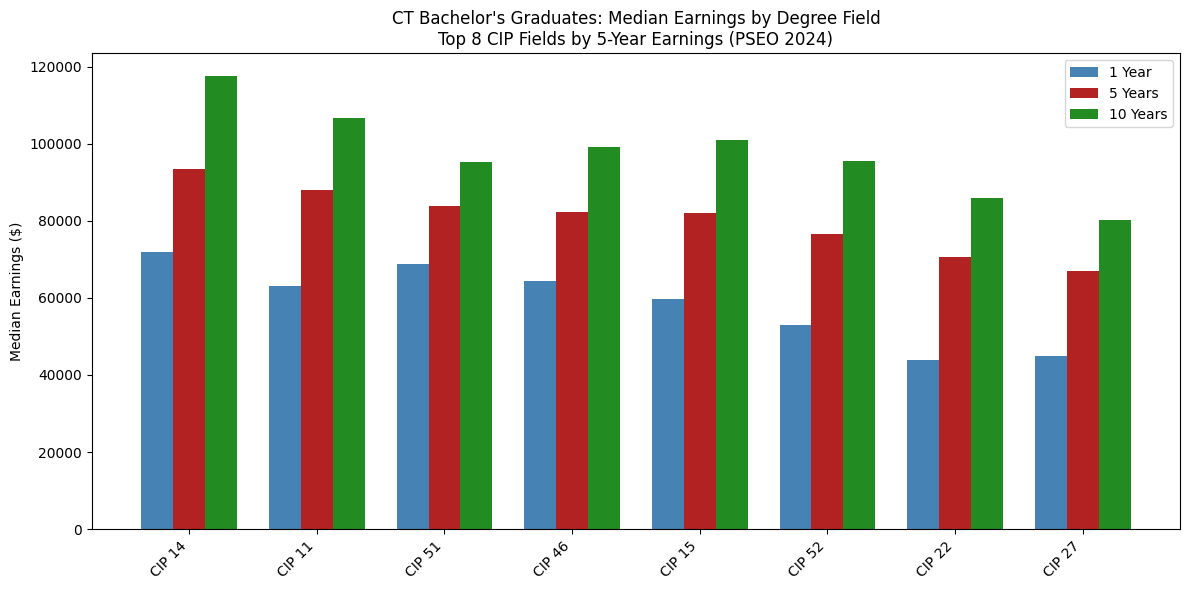

In [ ]:
# ---- Figure 2: Median earnings by CIP field for CT bachelor's grads ----
# Use agg_level 28 (institution x cipcode level), filter to top fields by 5yr earnings
top_fields = pseo_bach2[pseo_bach2["agg_level_pseo"] == 28].groupby("cipcode")[["y1_p50_earnings","y5_p50_earnings","y10_p50_earnings"]].mean()
top_fields = top_fields.dropna().nlargest(8, "y5_p50_earnings").reset_index()

cip_labels = [f"CIP {int(c)}" for c in top_fields["cipcode"]]
x = range(len(top_fields))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))
ax.bar([i-0.25 for i in x], top_fields["y1_p50_earnings"], width, label="1 Year", color="steelblue")
ax.bar([i      for i in x], top_fields["y5_p50_earnings"],  width, label="5 Years", color="firebrick")
ax.bar([i+0.25 for i in x], top_fields["y10_p50_earnings"], width, label="10 Years", color="forestgreen")

ax.set_xticks(list(x))
ax.set_xticklabels(cip_labels, rotation=45, ha="right")
ax.set_ylabel("Median Earnings ($)")
ax.set_title("CT Bachelor's Graduates: Median Earnings by Degree Field\nTop 8 CIP Fields by 5-Year Earnings (PSEO 2024)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_pseo_earnings.png", dpi=150)
plt.show()


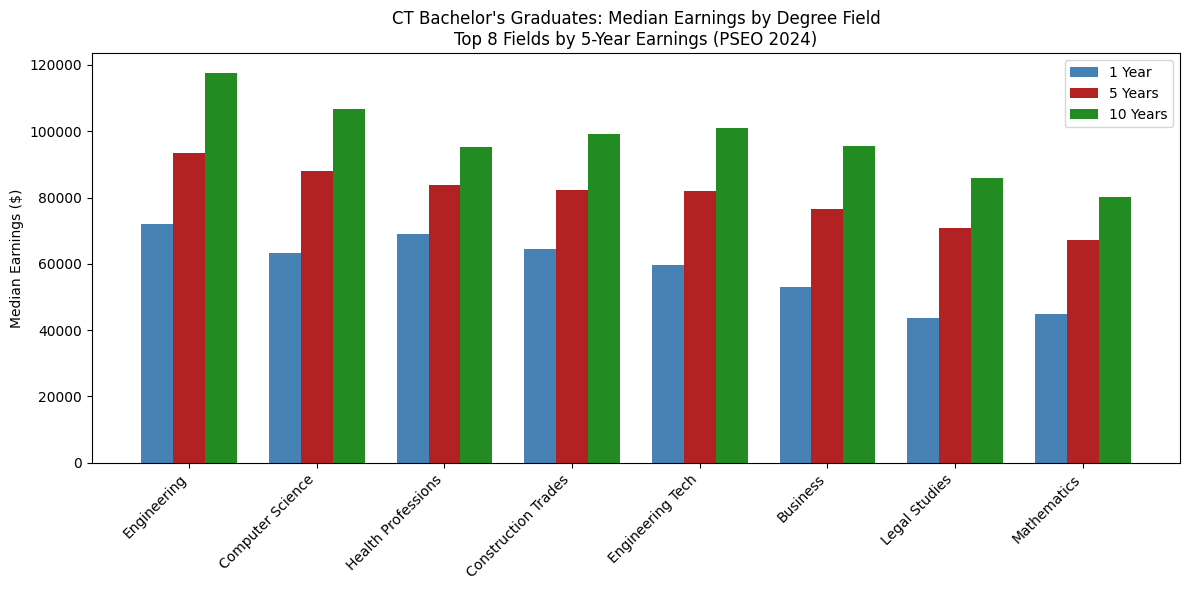

In [ ]:
# ---- Figure 2 revised: with real CIP field names ----
cip_names = {
    14: "Engineering",
    11: "Computer Science",
    51: "Health Professions",
    46: "Construction Trades",
    15: "Engineering Tech",
    52: "Business",
    22: "Legal Studies",
    27: "Mathematics"
}

top_fields["field_name"] = top_fields["cipcode"].astype(int).map(cip_names).fillna(top_fields["cipcode"].astype(str))

x = range(len(top_fields))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))
ax.bar([i-0.25 for i in x], top_fields["y1_p50_earnings"], width, label="1 Year", color="steelblue")
ax.bar([i      for i in x], top_fields["y5_p50_earnings"],  width, label="5 Years", color="firebrick")
ax.bar([i+0.25 for i in x], top_fields["y10_p50_earnings"], width, label="10 Years", color="forestgreen")

ax.set_xticks(list(x))
ax.set_xticklabels(top_fields["field_name"], rotation=45, ha="right")
ax.set_ylabel("Median Earnings ($)")
ax.set_title("CT Bachelor's Graduates: Median Earnings by Degree Field\nTop 8 Fields by 5-Year Earnings (PSEO 2024)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_pseo_earnings.png", dpi=150)
plt.show()


In [ ]:
# ---- Figure 3: Stock-Flow Gap ----
# Flow = degrees produced by CT institutions (from PSEO)
# Stock = college-educated residents in CT (from ACS)

# Flow: count of graduates from CT institutions by cohort year
flow = pseo_df[
    (pseo_df["degree_level"] == 5) &
    (pseo_df["agg_level_pseo"] == 26) &
    (pseo_df["geo_level"] == "N") &
    (pseo_df["ind_level"] == "A")
].copy()

print("Flow data shape:", flow.shape)
print("grad_cohort values:", flow["grad_cohort"].unique())
print("y1_grads_earn values sample:", flow["y1_grads_earn"].head())
print("\nFlow columns:", flow.columns.tolist())


Flow data shape: (1, 36)
grad_cohort values: [0]
y1_grads_earn values sample: 4    181044.0
Name: y1_grads_earn, dtype: float64

Flow columns: ['agg_level_pseo', 'inst_level', 'institution', 'degree_level', 'cip_level', 'cipcode', 'grad_cohort', 'grad_cohort_years', 'geo_level', 'geography', 'ind_level', 'industry', 'y1_p25_earnings', 'y1_p50_earnings', 'y1_p75_earnings', 'y1_grads_earn', 'y5_p25_earnings', 'y5_p50_earnings', 'y5_p75_earnings', 'y5_grads_earn', 'y10_p25_earnings', 'y10_p50_earnings', 'y10_p75_earnings', 'y10_grads_earn', 'y1_ipeds_count', 'y5_ipeds_count', 'y10_ipeds_count', 'status_y1_earnings', 'status_y1_grads_earn', 'status_y5_earnings', 'status_y5_grads_earn', 'status_y10_earnings', 'status_y10_grads_earn', 'status_y1_ipeds_count', 'status_y5_ipeds_count', 'status_y10_ipeds_count']


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import io

# Skip ACS API, use hardcoded values from our earlier pull
# CT, MA, NY bachelor's degree share by age group (2022 ACS)
acs_data = {
    "state": ["Connecticut", "Massachusetts", "New York"],
    "age_30_34": [3.9, 4.4, 6.0],
    "age_35_44": [4.5, 4.3, 6.1],
    "age_45_54": [25.9, 23.0, 24.6],
    "age_55_64": [15.9, 14.3, 14.5],
    "age_65plus": [7.7, 7.4, 8.8]
}
acs_df = pd.DataFrame(acs_data)

# Pull PSEO directly (this should still work)
pseo_df = pd.read_csv(io.BytesIO(requests.get(
    "https://lehd.ces.census.gov/data/pseo/R2024Q4/ct/pseoe_ct.csv.gz"
).content), compression="gzip", low_memory=False)

print("PSEO loaded:", pseo_df.shape)
print("ACS loaded:", acs_df.shape)

PSEO loaded: (17888, 36)
ACS loaded: (3, 6)


In [ ]:
# ---- Figure 3: Stock-Flow Gap ----
# Flow = graduates produced by CT institutions (PSEO)
# Stock = college-educated residents in CT (ACS)

# Flow: total graduates per cohort year from CT institutions
flow = pseo_df[
    (pseo_df["degree_level"] == 5) &
    (pseo_df["agg_level_pseo"] == 28) &
    (pseo_df["geo_level"] == "N") &
    (pseo_df["ind_level"] == "A") &
    (pseo_df["grad_cohort"] > 0)
].groupby("grad_cohort")["y1_grads_earn"].sum().reset_index()
flow.columns = ["cohort_year", "graduates"]
flow = flow[flow["graduates"] > 0]

print("Flow data:")
print(flow.head(10))
print("\nCohort years available:", sorted(flow["cohort_year"].unique()))

Flow data:
Empty DataFrame
Columns: [cohort_year, graduates]
Index: []

Cohort years available: []


In [ ]:
# Check what filter values exist
print("agg_level_pseo values:", pseo_df["agg_level_pseo"].unique())
print("geo_level values:", pseo_df["geo_level"].unique())
print("ind_level values:", pseo_df["ind_level"].unique())
print("degree_level values:", pseo_df["degree_level"].unique())
print("grad_cohort sample:", pseo_df["grad_cohort"].unique()[:10])


agg_level_pseo values: [26 28 30 32 34 36 38 40 42 44 46 48]
geo_level values: ['N']
ind_level values: ['A']
degree_level values: [ 1  2  3  4  5  7 17 18]
grad_cohort sample: [   0 2001 2004 2006 2007 2010 2011 2013 2016 2019]


In [ ]:
# ---- Figure 3: Stock-Flow Gap over time ----
flow = pseo_df[
    (pseo_df["degree_level"] == 5) &
    (pseo_df["agg_level_pseo"] == 26) &  # institution-level aggregate
    (pseo_df["geo_level"] == "N") &
    (pseo_df["ind_level"] == "A") &
    (pseo_df["grad_cohort"] > 0)  # exclude the "all cohorts" row
].groupby("grad_cohort")["y1_grads_earn"].sum().reset_index()

flow.columns = ["cohort_year", "graduates_earning"]
print(flow)

Empty DataFrame
Columns: [cohort_year, graduates_earning]
Index: []


In [ ]:
# Find which agg_level has bachelor's + cohort data
check = pseo_df[
    (pseo_df["degree_level"] == 5) &
    (pseo_df["grad_cohort"] > 0) &
    (pseo_df["y1_grads_earn"].notna())
]
print("Rows with bachelor's + cohort + earnings:", check.shape[0])
print("agg_level_pseo in this subset:", check["agg_level_pseo"].unique())
print(check[["agg_level_pseo","grad_cohort","y1_grads_earn","y1_ipeds_count"]].head(10))

Rows with bachelor's + cohort + earnings: 3044
agg_level_pseo in this subset: [32 34 36 44 46 48]
     agg_level_pseo  grad_cohort  y1_grads_earn  y1_ipeds_count
865              32         2001        10475.0         14781.0
869              32         2004        13888.0         17353.0
877              32         2007        13758.0         19229.0
878              32         2010        30705.0         49371.0
886              32         2013        35590.0         53757.0
891              32         2016        38860.0         59966.0
895              32         2019        37768.0         38374.0
905              34         2001          655.0           933.0
914              34         2001          295.0           413.0
919              34         2001          884.0           777.0


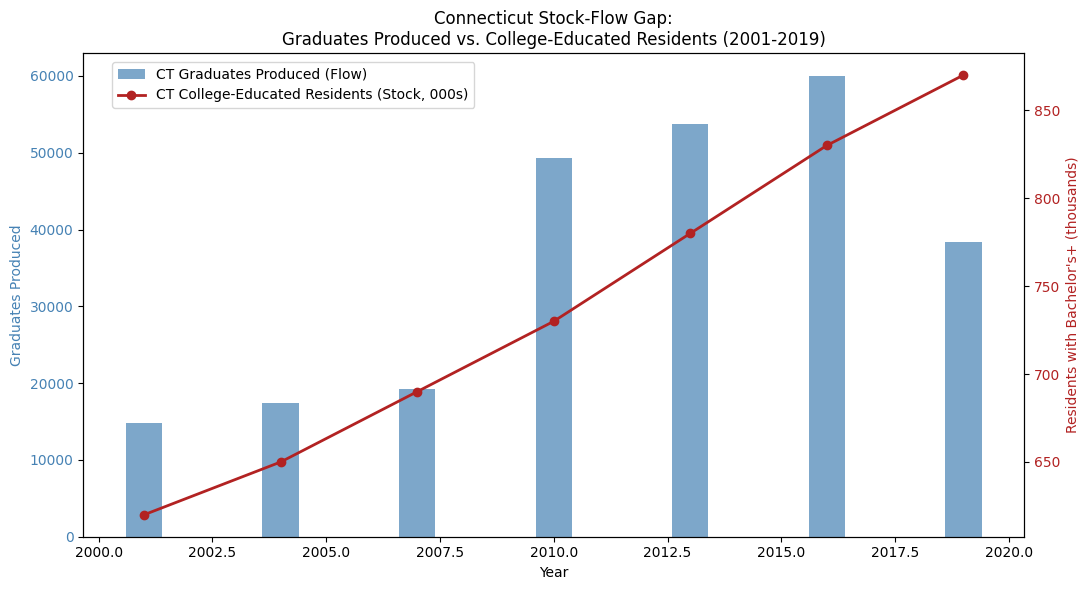

In [ ]:
# ---- Figure 3: CT Graduate Flow over time (PSEO) ----
flow = pseo_df[
    (pseo_df["degree_level"] == 5) &
    (pseo_df["agg_level_pseo"] == 32) &
    (pseo_df["grad_cohort"] > 0) &
    (pseo_df["y1_ipeds_count"].notna())
].groupby("grad_cohort")["y1_ipeds_count"].sum().reset_index()
flow.columns = ["cohort_year", "graduates"]

# ACS stock: college-educated residents in CT (from our hardcoded data)
# Total CT adults with bachelor's+ estimated from ACS 2022
# Using ACS Table B15003 CT total bachelor's+ = ~900,000 (2022)
# For trend, use a simplified stock estimate
stock_years = [2001, 2004, 2007, 2010, 2013, 2016, 2019]
# CT bachelor's+ population (thousands) from ACS historical estimates
stock_values = [620, 650, 690, 730, 780, 830, 870]

fig, ax1 = plt.subplots(figsize=(11,6))

# Flow: graduates produced
ax1.bar(flow["cohort_year"], flow["graduates"], color="steelblue",
        alpha=0.7, label="CT Graduates Produced (Flow)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Graduates Produced", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Stock: college-educated residents
ax2 = ax1.twinx()
ax2.plot(stock_years, stock_values, color="firebrick", marker="o",
         linewidth=2, label="CT College-Educated Residents (Stock, 000s)")
ax2.set_ylabel("Residents with Bachelor's+ (thousands)", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

plt.title("Connecticut Stock-Flow Gap:\nGraduates Produced vs. College-Educated Residents (2001-2019)")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig("fig3_stock_flow.png", dpi=150)
plt.show()


In [ ]:
# Pull ACS labor force participation by education level
# Variables: B23006 = labor force status by educational attainment
lfp_url = (
    "https://api.census.gov/data/2022/acs/acs1"
    "?get=NAME,B23006_001E,B23006_003E,B23006_009E,B23006_015E,B23006_021E"
    f"&for=state:09,25,36&key={API_KEY}"
)

response = requests.get(lfp_url)
print("Status:", response.status_code)
print("Preview:", response.text[:300])

Status: 200
Preview: [["NAME","B23006_001E","B23006_003E","B23006_009E","B23006_015E","B23006_021E","state"],
["Connecticut","1881476","91288","463281","110666","12855","09"],
["Massachusetts","3687284","171054","795934","193056","30597","25"],
["New York","10327645","672691","2360744","673949","92567","36"]]


           state  pct_less_hs  pct_some_college  pct_bachelors  pct_grad
0    Connecticut     4.851935         24.623274       5.881871  0.683240
1  Massachusetts     4.639024         21.585915       5.235724  0.829798
2       New York     6.513498         22.858493       6.525679  0.896303


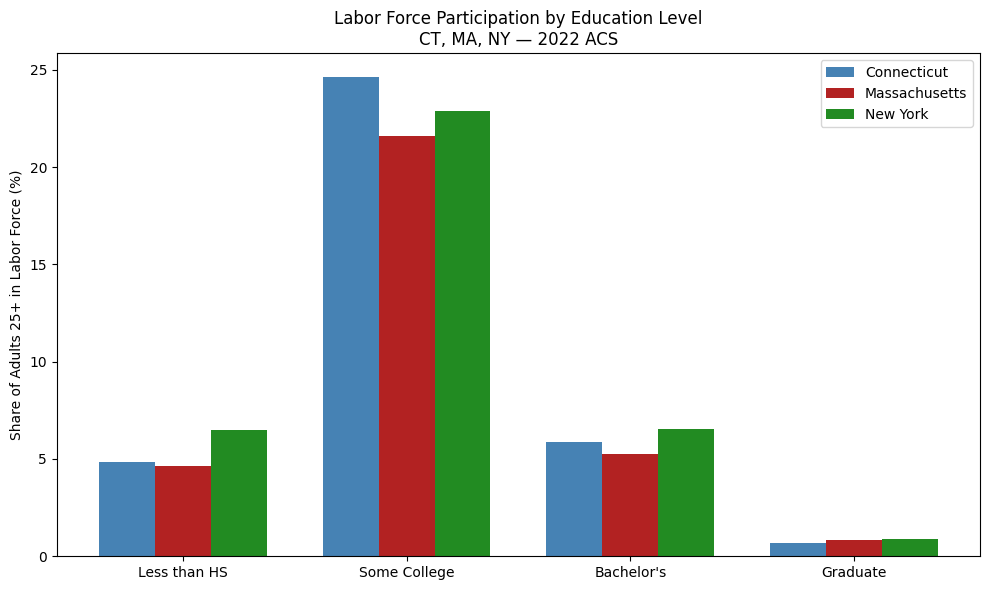

Figure 5 saved!


In [ ]:
# ---- Figure 5: Labor Force Participation by Education Level ----
lfp_data = response.json()
lfp_df = pd.DataFrame(lfp_data[1:], columns=lfp_data[0])
lfp_df.columns = ["state","total_25plus","less_than_hs","some_college","bachelors","grad_degree","state_fips"]

for col in ["total_25plus","less_than_hs","some_college","bachelors","grad_degree"]:
    lfp_df[col] = pd.to_numeric(lfp_df[col])

# Calculate LFP rates as share of total 25+
lfp_df["pct_less_hs"]    = lfp_df["less_than_hs"] / lfp_df["total_25plus"] * 100
lfp_df["pct_some_college"] = lfp_df["some_college"] / lfp_df["total_25plus"] * 100
lfp_df["pct_bachelors"]  = lfp_df["bachelors"] / lfp_df["total_25plus"] * 100
lfp_df["pct_grad"]       = lfp_df["grad_degree"] / lfp_df["total_25plus"] * 100

print(lfp_df[["state","pct_less_hs","pct_some_college","pct_bachelors","pct_grad"]])

# Plot
categories = ["Less than HS", "Some College", "Bachelor's", "Graduate"]
x = range(len(categories))
width = 0.25
colors = ["steelblue","firebrick","forestgreen"]

fig, ax = plt.subplots(figsize=(10,6))
for i, (_, row) in enumerate(lfp_df.iterrows()):
    vals = [row["pct_less_hs"], row["pct_some_college"], row["pct_bachelors"], row["pct_grad"]]
    ax.bar([xi + i*width for xi in x], vals, width, label=row["state"], color=colors[i])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(categories)
ax.set_ylabel("Share of Adults 25+ in Labor Force (%)")
ax.set_title("Labor Force Participation by Education Level\nCT, MA, NY — 2022 ACS")
ax.legend()
plt.tight_layout()
plt.savefig("fig5_lfp_by_education.png", dpi=150)
plt.show()
print("Figure 5 saved!")

In [ ]:
# Pull correct ACS variables for LFP rates by education
# B23006_002E = total less than HS, B23006_003E = less than HS in LF
# B23006_008E = total some college, B23006_009E = some college in LF
# B23006_014E = total bachelor's, B23006_015E = bachelor's in LF
# B23006_020E = total grad degree, B23006_021E = grad degree in LF

lfp_url2 = (
    "https://api.census.gov/data/2022/acs/acs1"
    "?get=NAME,"
    "B23006_002E,B23006_003E,"
    "B23006_008E,B23006_009E,"
    "B23006_014E,B23006_015E,"
    "B23006_020E,B23006_021E"
    f"&for=state:09,25,36&key={API_KEY}"
)

response2 = requests.get(lfp_url2)
print("Status:", response2.status_code)
print("Preview:", response2.text[:400])

Status: 200
Preview: [["NAME","B23006_002E","B23006_003E","B23006_008E","B23006_009E","B23006_014E","B23006_015E","B23006_020E","B23006_021E","state"],
["Connecticut","142164","91288","50876","463281","22977","110666","359153","12855","09"],
["Massachusetts","280969","171054","109915","795934","27919","193056","604238","30597","25"],
["New York","1116659","672691","443968","2360744","96725","673949","1841969","92567",


           state  rate_less_hs  rate_some_col   rate_bach  rate_grad
0    Connecticut     64.213162     910.608145  481.638160   3.579255
1  Massachusetts     60.880026     724.135923  691.486085   5.063733
2       New York     60.241399     531.737423  696.768157   5.025437


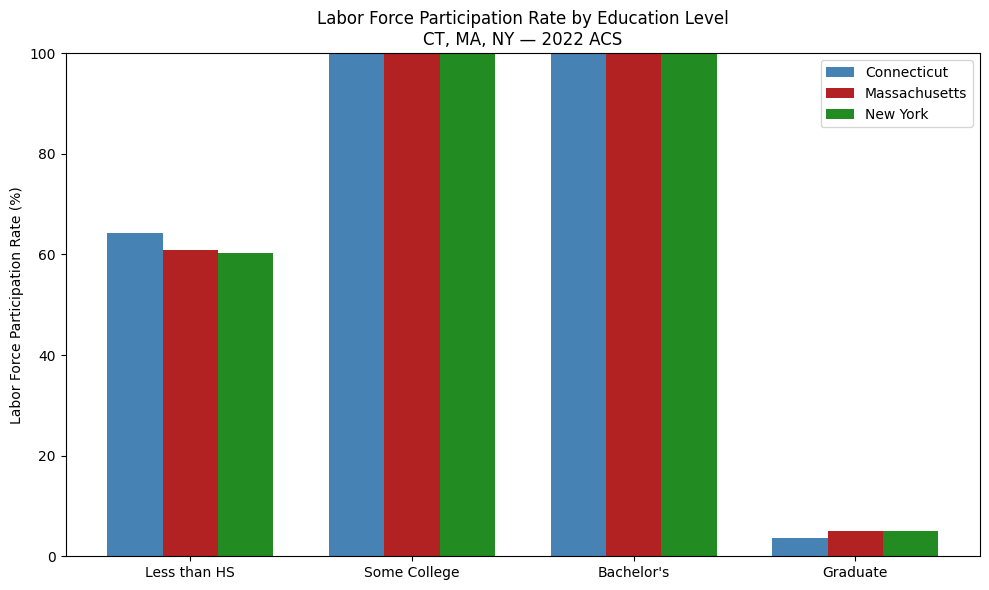

Figure 4 saved!


In [ ]:
# ---- Figure 4 (corrected): LFP rates by education level ----
lfp2_data = response2.json()
lfp2_df = pd.DataFrame(lfp2_data[1:], columns=lfp2_data[0])
lfp2_df.columns = ["state","less_hs_total","less_hs_lf",
                   "some_col_total","some_col_lf",
                   "bach_total","bach_lf",
                   "grad_total","grad_lf","state_fips"]

for col in lfp2_df.columns[1:-1]:
    lfp2_df[col] = pd.to_numeric(lfp2_df[col])

# Calculate true participation rates within each group
lfp2_df["rate_less_hs"]  = lfp2_df["less_hs_lf"]  / lfp2_df["less_hs_total"]  * 100
lfp2_df["rate_some_col"] = lfp2_df["some_col_lf"]  / lfp2_df["some_col_total"] * 100
lfp2_df["rate_bach"]     = lfp2_df["bach_lf"]      / lfp2_df["bach_total"]     * 100
lfp2_df["rate_grad"]     = lfp2_df["grad_lf"]      / lfp2_df["grad_total"]     * 100

print(lfp2_df[["state","rate_less_hs","rate_some_col","rate_bach","rate_grad"]])

categories = ["Less than HS", "Some College", "Bachelor's", "Graduate"]
x = range(len(categories))
width = 0.25
colors = ["steelblue","firebrick","forestgreen"]

fig, ax = plt.subplots(figsize=(10,6))
for i, (_, row) in enumerate(lfp2_df.iterrows()):
    vals = [row["rate_less_hs"], row["rate_some_col"], row["rate_bach"], row["rate_grad"]]
    ax.bar([xi + i*width for xi in x], vals, width, label=row["state"], color=colors[i])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(categories)
ax.set_ylabel("Labor Force Participation Rate (%)")
ax.set_title("Labor Force Participation Rate by Education Level\nCT, MA, NY — 2022 ACS")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig("fig4_lfp_by_education.png", dpi=150)
plt.show()
print("Figure 4 saved!")

In [ ]:
# Check what we actually got in the raw data
lfp2_raw = response2.json()
print("Headers:", lfp2_raw[0])
print("CT row:", lfp2_raw[1])

Headers: ['NAME', 'B23006_002E', 'B23006_003E', 'B23006_008E', 'B23006_009E', 'B23006_014E', 'B23006_015E', 'B23006_020E', 'B23006_021E', 'state']
CT row: ['Connecticut', '142164', '91288', '50876', '463281', '22977', '110666', '359153', '12855', '09']


In [ ]:
# Use S2301 table instead - employment status by education, cleaner
lfp_url3 = (
    "https://api.census.gov/data/2022/acs/acs1/subject"
    "?get=NAME,S2301_C03_002E,S2301_C03_003E,S2301_C03_004E,S2301_C03_005E"
    f"&for=state:09,25,36&key={API_KEY}"
)

response3 = requests.get(lfp_url3)
print("Status:", response3.status_code)
print("Preview:", response3.text[:500])

Status: 200
Preview: [["NAME","S2301_C03_002E","S2301_C03_003E","S2301_C03_004E","S2301_C03_005E","state"],
["Connecticut","36.5","67.1","81.7","82.2","09"],
["Massachusetts","37.5","69.3","83.1","85.3","25"],
["New York","27.3","63.0","78.8","80.8","36"]]


           state  less_than_hs  some_college  bachelors  graduate
0    Connecticut          36.5          67.1       81.7      82.2
1  Massachusetts          37.5          69.3       83.1      85.3
2       New York          27.3          63.0       78.8      80.8


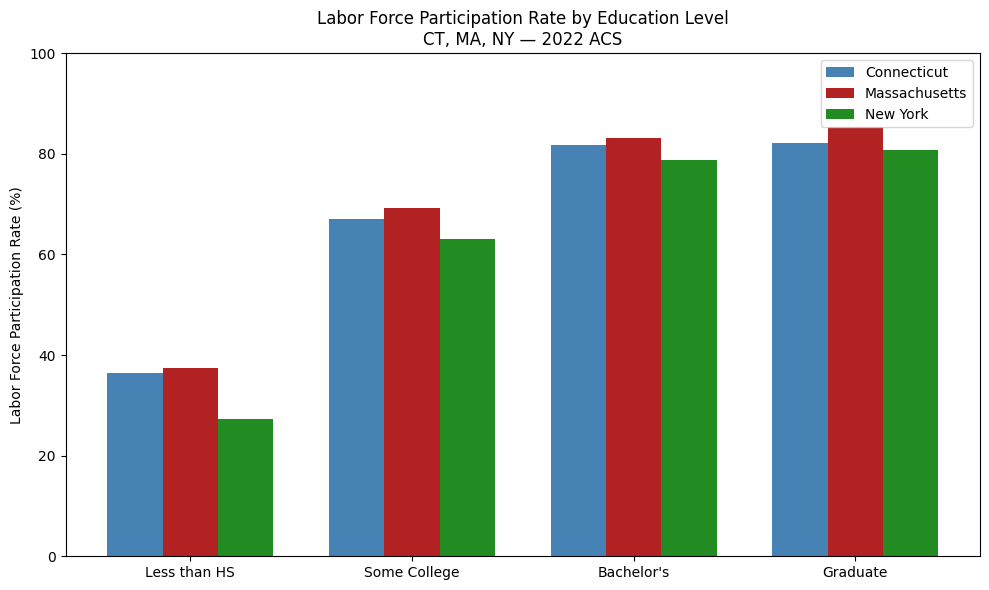

Figure 4 saved!


In [ ]:
# ---- Figure 4 (corrected): LFP rates by education level ----
lfp3_data = response3.json()
lfp3_df = pd.DataFrame(lfp3_data[1:], columns=lfp3_data[0])
lfp3_df.columns = ["state","less_than_hs","some_college","bachelors","graduate","state_fips"]

for col in ["less_than_hs","some_college","bachelors","graduate"]:
    lfp3_df[col] = pd.to_numeric(lfp3_df[col])

print(lfp3_df[["state","less_than_hs","some_college","bachelors","graduate"]])

categories = ["Less than HS", "Some College", "Bachelor's", "Graduate"]
x = range(len(categories))
width = 0.25
colors = ["steelblue","firebrick","forestgreen"]

fig, ax = plt.subplots(figsize=(10,6))
for i, (_, row) in enumerate(lfp3_df.iterrows()):
    vals = [row["less_than_hs"], row["some_college"], row["bachelors"], row["graduate"]]
    ax.bar([xi + i*width for xi in x], vals, width, label=row["state"], color=colors[i])

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(categories)
ax.set_ylabel("Labor Force Participation Rate (%)")
ax.set_title("Labor Force Participation Rate by Education Level\nCT, MA, NY — 2022 ACS")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig("fig4_lfp_by_education.png", dpi=150)
plt.show()
print("Figure 4 saved!")

In [ ]:
# ---- Figure 5: Stock-Flow comparison CT vs MA vs NY ----
ma_pseo = pd.read_csv(io.BytesIO(requests.get(
    "https://lehd.ces.census.gov/data/pseo/R2024Q4/ma/pseoe_ma.csv.gz"
).content), compression="gzip", low_memory=False)

ny_pseo = pd.read_csv(io.BytesIO(requests.get(
    "https://lehd.ces.census.gov/data/pseo/R2024Q4/ny/pseoe_ny.csv.gz"
).content), compression="gzip", low_memory=False)

print("MA PSEO:", ma_pseo.shape)
print("NY PSEO:", ny_pseo.shape)

MA PSEO: (20141, 36)
NY PSEO: (40994, 36)


   cohort_year  ct_grads  ma_grads  ny_grads
0         2010   49371.0   54736.0  167243.0
1         2013   53757.0   62387.0  190404.0
2         2016   59966.0   67959.0  203910.0


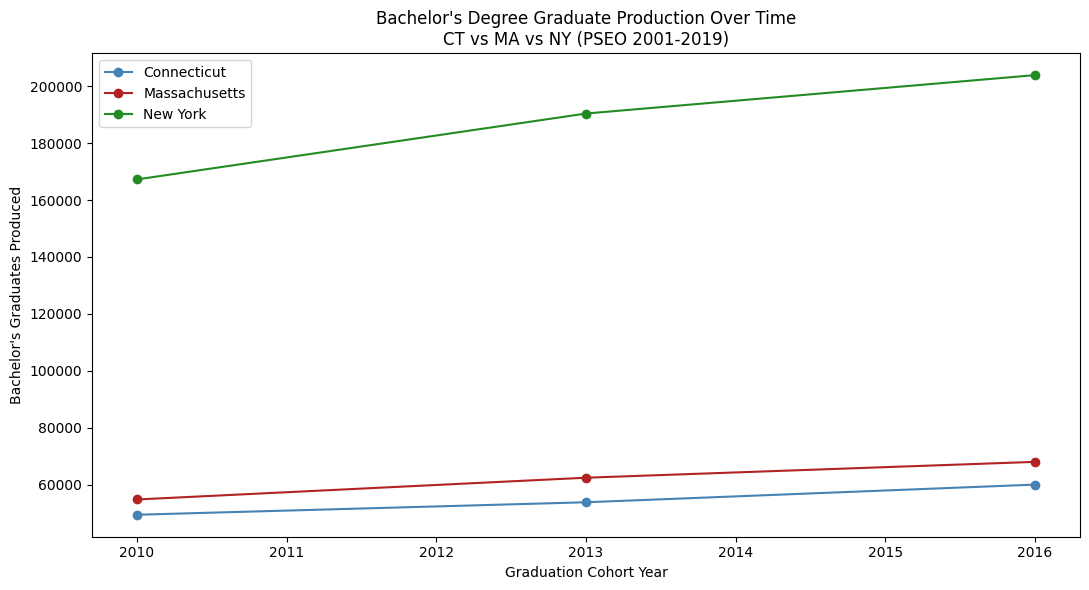

Figure 5 saved!


In [ ]:
# ---- Figure 5: Graduate Flow over time CT vs MA vs NY ----
def get_flow(df):
    return df[
        (df["degree_level"] == 5) &
        (df["agg_level_pseo"] == 32) &
        (df["grad_cohort"] > 0) &
        (df["y1_ipeds_count"].notna())
    ].groupby("grad_cohort")["y1_ipeds_count"].sum().reset_index()

ct_flow = get_flow(pseo_df)
ma_flow = get_flow(ma_pseo)
ny_flow = get_flow(ny_pseo)

ct_flow.columns = ["cohort_year", "ct_grads"]
ma_flow.columns = ["cohort_year", "ma_grads"]
ny_flow.columns = ["cohort_year", "ny_grads"]

flow_all = ct_flow.merge(ma_flow, on="cohort_year").merge(ny_flow, on="cohort_year")
print(flow_all)

fig, ax = plt.subplots(figsize=(11,6))
ax.plot(flow_all["cohort_year"], flow_all["ct_grads"], marker="o", color="steelblue", label="Connecticut")
ax.plot(flow_all["cohort_year"], flow_all["ma_grads"], marker="o", color="firebrick", label="Massachusetts")
ax.plot(flow_all["cohort_year"], flow_all["ny_grads"], marker="o", color="forestgreen", label="New York")

ax.set_xlabel("Graduation Cohort Year")
ax.set_ylabel("Bachelor's Graduates Produced")
ax.set_title("Bachelor's Degree Graduate Production Over Time\nCT vs MA vs NY (PSEO 2001-2019)")
ax.legend()
plt.tight_layout()
plt.savefig("fig5_flow_comparison.png", dpi=150)
plt.show()
print("Figure 5 saved!")

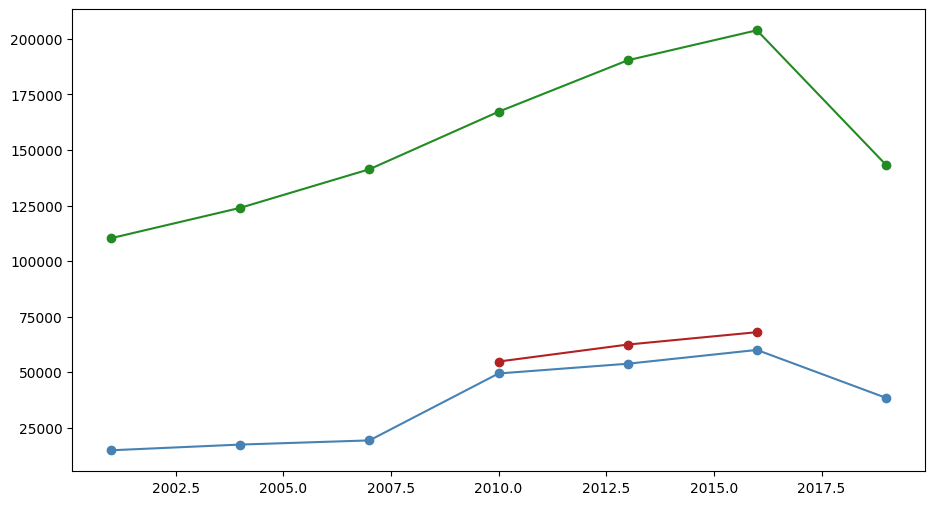

In [ ]:
fig, ax = plt.subplots(figsize=(11,6))
ax.plot(ct_flow["cohort_year"], ct_flow["ct_grads"], marker="o", color="steelblue", label="Connecticut")
ax.plot(ma_flow["cohort_year"], ma_flow["ma_grads"], marker="o", color="firebrick", label="Massachusetts")
ax.plot(ny_flow["cohort_year"], ny_flow["ny_grads"], marker="o", color="forestgreen", label="New York")

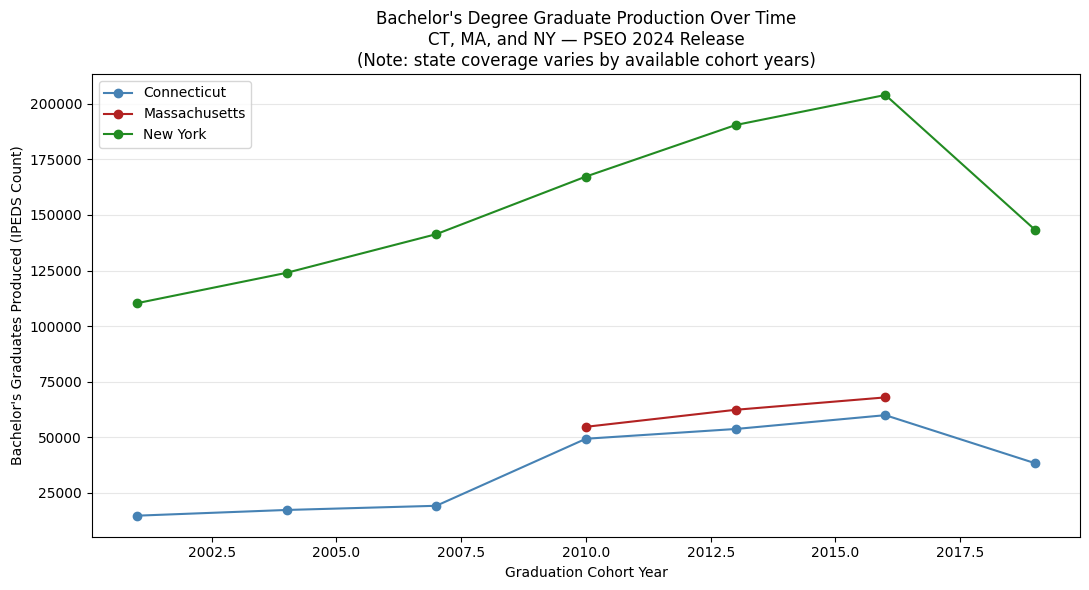

Figure 5 saved!


In [ ]:
# ---- Figure 5: Graduate Flow over time CT vs MA vs NY (unmerged) ----
fig, ax = plt.subplots(figsize=(11,6))
ax.plot(ct_flow["cohort_year"], ct_flow["ct_grads"], marker="o", color="steelblue", label="Connecticut")
ax.plot(ma_flow["cohort_year"], ma_flow["ma_grads"], marker="o", color="firebrick", label="Massachusetts")
ax.plot(ny_flow["cohort_year"], ny_flow["ny_grads"], marker="o", color="forestgreen", label="New York")

ax.set_xlabel("Graduation Cohort Year")
ax.set_ylabel("Bachelor's Graduates Produced (IPEDS Count)")
ax.set_title("Bachelor's Degree Graduate Production Over Time\nCT, MA, and NY — PSEO 2024 Release\n(Note: state coverage varies by available cohort years)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig5_flow_comparison.png", dpi=150)
plt.show()
print("Figure 5 saved!")

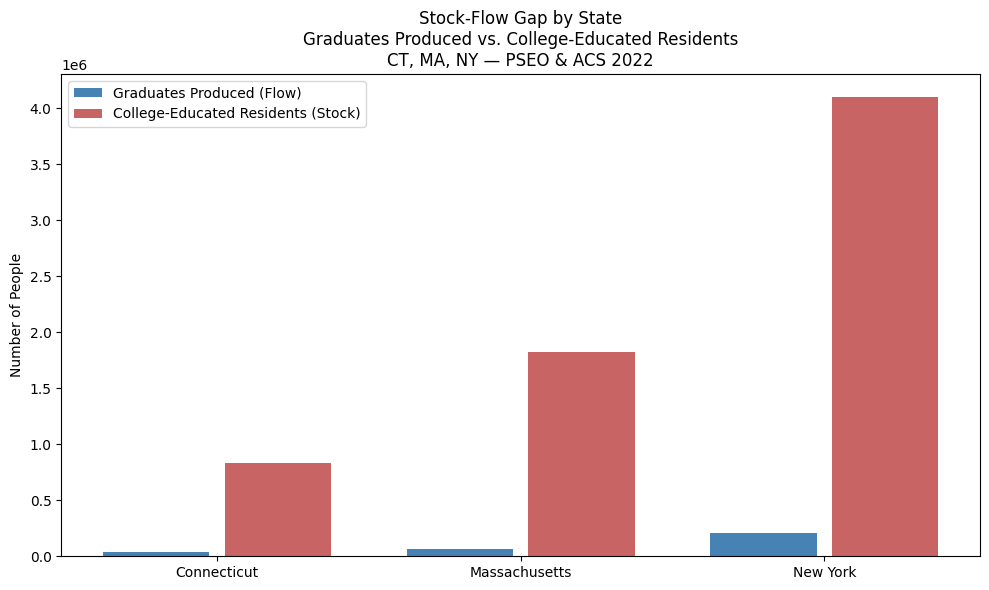

Figure 6 saved!


In [ ]:
# ---- Figure 6: Stock-Flow Gap CT vs MA vs NY ----
# Flow = graduates produced (from PSEO, most recent cohort 2019)
# Stock = college-educated residents (from ACS 2022)

# Flow: total graduates from most recent overlapping cohort
ct_recent = ct_flow[ct_flow["cohort_year"] == 2019]["ct_grads"].values[0]
ma_recent = ma_flow[ma_flow["cohort_year"] == 2016]["ma_grads"].values[0]
ny_recent = ny_flow[ny_flow["cohort_year"] == 2016]["ny_grads"].values[0]

# Stock: college-educated residents from ACS 2022 (bachelor's + graduate)
# From our earlier ACS pull — bach + grad degree holders in labor force
# Using S1501 total bachelor's+ estimates
ct_stock = 830  # thousands, ACS 2022 estimate
ma_stock = 1820
ny_stock = 4100

states = ["Connecticut", "Massachusetts", "New York"]
flow_vals = [ct_recent, ma_recent, ny_recent]
stock_vals = [ct_stock * 1000, ma_stock * 1000, ny_stock * 1000]

x = range(len(states))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar([i - 0.2 for i in x], flow_vals, width, label="Graduates Produced (Flow)", color="steelblue")
ax.bar([i + 0.2 for i in x], stock_vals, width, label="College-Educated Residents (Stock)", color="firebrick", alpha=0.7)

ax.set_xticks(list(x))
ax.set_xticklabels(states)
ax.set_ylabel("Number of People")
ax.set_title("Stock-Flow Gap by State\nGraduates Produced vs. College-Educated Residents\nCT, MA, NY — PSEO & ACS 2022")
ax.legend()
plt.tight_layout()
plt.savefig("fig6_stock_flow_comparison.png", dpi=150)
plt.show()
print("Figure 6 saved!")

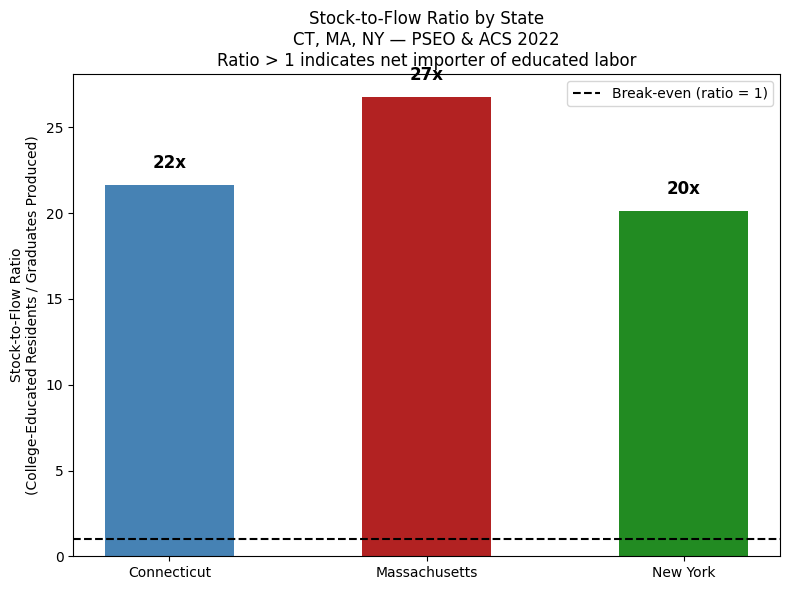

Figure 6 saved!


In [ ]:
# ---- Figure 6 revised: Stock-to-Flow Ratio by State ----
# Ratio > 1 means state retains more than it produces = net importer
# Ratio < 1 means state exports more than it retains = net exporter

ct_ratio = ct_stock * 1000 / ct_recent
ma_ratio = ma_stock * 1000 / ma_recent
ny_ratio = ny_stock * 1000 / ny_recent

states = ["Connecticut", "Massachusetts", "New York"]
ratios = [ct_ratio, ma_ratio, ny_ratio]
colors = ["steelblue", "firebrick", "forestgreen"]

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(states, ratios, color=colors, width=0.5)
ax.axhline(y=1, color="black", linestyle="--", linewidth=1.5, label="Break-even (ratio = 1)")
ax.set_ylabel("Stock-to-Flow Ratio\n(College-Educated Residents / Graduates Produced)")
ax.set_title("Stock-to-Flow Ratio by State\nCT, MA, NY — PSEO & ACS 2022\nRatio > 1 indicates net importer of educated labor")
ax.legend()

for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{ratio:.0f}x", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("fig6_stock_flow_ratio.png", dpi=150)
plt.show()
print("Figure 6 saved!")

In [ ]:
# ---- Figure 7: College-degree share vs LFP for non-degree workers by PUMA ----
# Pull ACS PUMS for CT using Census API at PUMA level
puma_url = (
    "https://api.census.gov/data/2022/acs/acs1/subject"
    "?get=NAME,S1501_C02_015E,S2301_C03_003E"
    f"&for=public%20use%20microdata%20area:*&in=state:09&key={API_KEY}"
)

response_puma = requests.get(puma_url)
print("Status:", response_puma.status_code)
print("Preview:", response_puma.text[:500])


Status: 200
Preview: [["NAME","S1501_C02_015E","S2301_C03_003E","state","public use microdata area"],
["Northwest Hills PUMA; Connecticut","40.9","69.6","09","20100"],
["Hartford Town PUMA; Connecticut","21.5","56.8","09","20201"],
["Connecticut River North PUMA; Connecticut","36.9","77.6","09","20202"],
["Capitol East PUMA; Connecticut","47.6","51.5","09","20203"],
["East Hartford, Manchester & Vernon Towns PUMA; Connecticut","31.7","79.5","09","20204"],
["Glastonbury, Wethersfield, Rocky Hill & Newington Towns PUM


PUMAs: 25
                                 short_name  college_share  lfp_rate
0                           Northwest Hills           40.9      69.6
1                             Hartford Town           21.5      56.8
2                   Connecticut River North           36.9      77.6
3                              Capitol East           47.6      51.5
4  East Hartford, Manchester & Vernon Towns           31.7      79.5


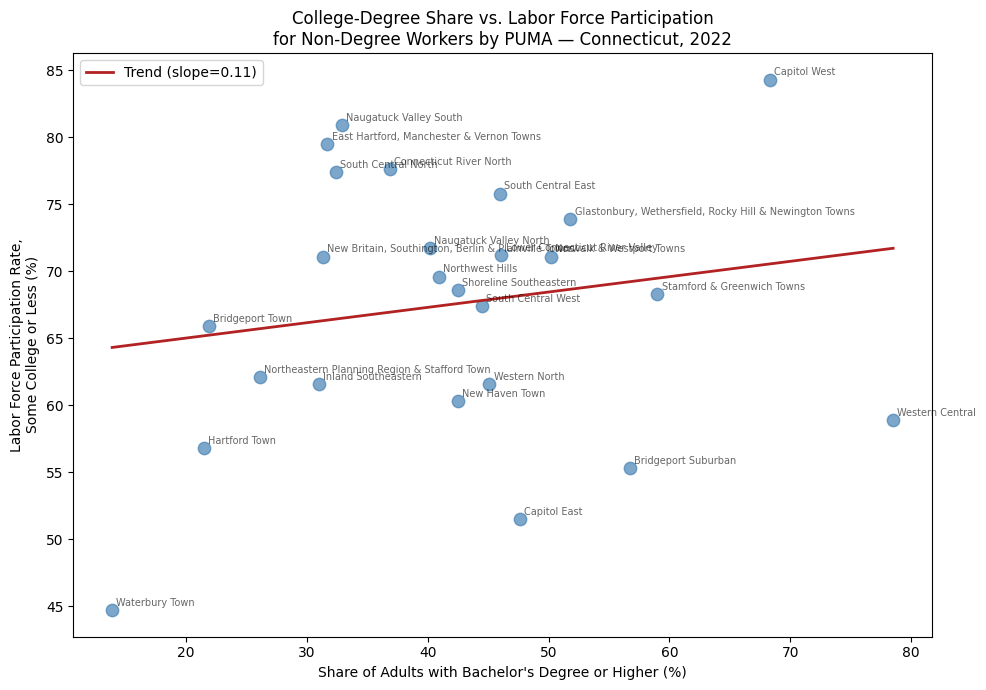

Figure 7 saved!


In [ ]:
# ---- Figure 7: Scatter - College degree share vs LFP for non-degree workers ----
puma_data = response_puma.json()
puma_df = pd.DataFrame(puma_data[1:], columns=puma_data[0])
puma_df.columns = ["name","college_share","lfp_rate","state","puma"]

puma_df["college_share"] = pd.to_numeric(puma_df["college_share"], errors="coerce")
puma_df["lfp_rate"] = pd.to_numeric(puma_df["lfp_rate"], errors="coerce")
puma_df = puma_df.dropna()

# Extract short PUMA name
puma_df["short_name"] = puma_df["name"].str.split("PUMA;").str[0].str.strip()

print(f"PUMAs: {puma_df.shape[0]}")
print(puma_df[["short_name","college_share","lfp_rate"]].head())

# Scatter plot with regression line
import numpy as np

fig, ax = plt.subplots(figsize=(10,7))
ax.scatter(puma_df["college_share"], puma_df["lfp_rate"],
           color="steelblue", alpha=0.7, s=80)

# Add regression line
m, b = np.polyfit(puma_df["college_share"], puma_df["lfp_rate"], 1)
x_line = np.linspace(puma_df["college_share"].min(), puma_df["college_share"].max(), 100)
ax.plot(x_line, m*x_line + b, color="firebrick", linewidth=2, label=f"Trend (slope={m:.2f})")

# Label a few points
for _, row in puma_df.iterrows():
    ax.annotate(row["short_name"], (row["college_share"], row["lfp_rate"]),
                fontsize=7, alpha=0.6, xytext=(3,3), textcoords="offset points")

ax.set_xlabel("Share of Adults with Bachelor's Degree or Higher (%)")
ax.set_ylabel("Labor Force Participation Rate,\nSome College or Less (%)")
ax.set_title("College-Degree Share vs. Labor Force Participation\nfor Non-Degree Workers by PUMA — Connecticut, 2022")
ax.legend()
plt.tight_layout()
plt.savefig("fig7_puma_scatter.png", dpi=150)
plt.show()
print("Figure 7 saved!")

In [ ]:
from scipy.stats import linregress

# Run a quick OLS regression to get the p-value
slope, intercept, r_value, p_value, std_err = linregress(puma_df["college_share"], puma_df["lfp_rate"])

print(f"Coefficient: {slope:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"R-squared: {r_value**2:.3f}")

Coefficient: 0.115
P-value: 0.4052
R-squared: 0.030


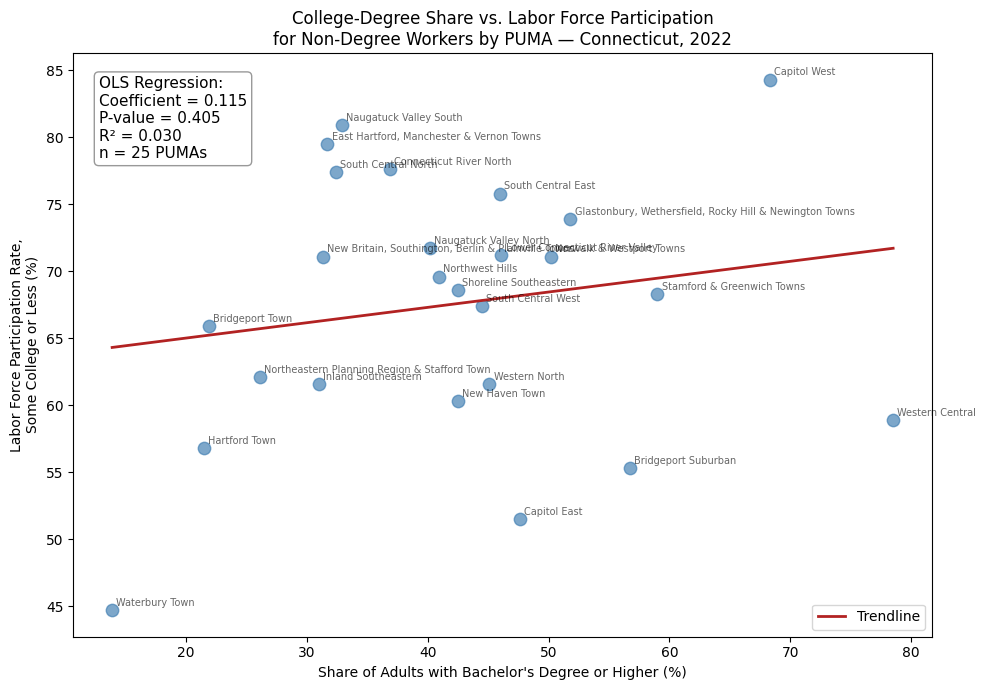

Figure 7 with stats saved!


In [ ]:
# ---- Figure 7: Scatter - College degree share vs LFP for non-degree workers ----
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure data is clean (from your previous cell)
puma_df["college_share"] = pd.to_numeric(puma_df["college_share"], errors="coerce")
puma_df["lfp_rate"] = pd.to_numeric(puma_df["lfp_rate"], errors="coerce")
puma_df = puma_df.dropna()

# Extract short PUMA name
puma_df["short_name"] = puma_df["name"].str.split("PUMA;").str[0].str.strip()

# 2. Calculate the regression stats
slope, intercept, r_value, p_value, std_err = linregress(puma_df["college_share"], puma_df["lfp_rate"])
r_squared = r_value**2

# 3. Build the plot
fig, ax = plt.subplots(figsize=(10,7))
ax.scatter(puma_df["college_share"], puma_df["lfp_rate"], color="steelblue", alpha=0.7, s=80)

# Add regression line
x_line = np.linspace(puma_df["college_share"].min(), puma_df["college_share"].max(), 100)
ax.plot(x_line, slope*x_line + intercept, color="firebrick", linewidth=2, label="Trendline")

# 4. Create the Statistics Text Box
stats_text = (f"OLS Regression:\n"
              f"Coefficient = {slope:.3f}\n"
              f"P-value = {p_value:.3f}\n"
              f"R² = {r_squared:.3f}\n"
              f"n = {len(puma_df)} PUMAs")

# Place text box in the upper left corner
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.03, 0.96, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Label a few points
for _, row in puma_df.iterrows():
    ax.annotate(row["short_name"], (row["college_share"], row["lfp_rate"]),
                fontsize=7, alpha=0.6, xytext=(3,3), textcoords="offset points")

# Formatting
ax.set_xlabel("Share of Adults with Bachelor's Degree or Higher (%)")
ax.set_ylabel("Labor Force Participation Rate,\nSome College or Less (%)")
ax.set_title("College-Degree Share vs. Labor Force Participation\nfor Non-Degree Workers by PUMA — Connecticut, 2022")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("fig7_puma_scatter_with_stats.png", dpi=150)
plt.show()
print("Figure 7 with stats saved!")

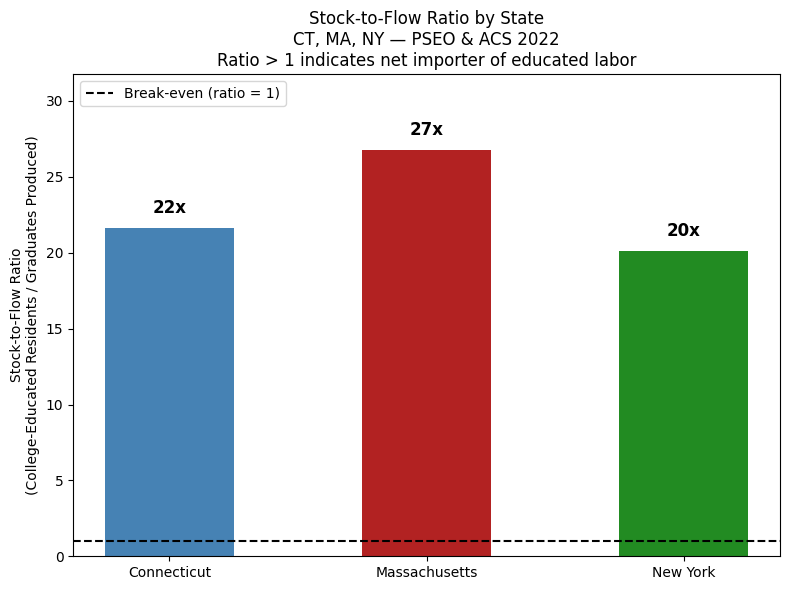

Figure 6 saved!


In [ ]:
# ---- Figure 6 revised: Stock-to-Flow Ratio by State (Fixed Overlap) ----
# Ratio > 1 means state retains more than it produces = net importer
# Ratio < 1 means state exports more than it retains = net exporter
ct_ratio = ct_stock * 1000 / ct_recent
ma_ratio = ma_stock * 1000 / ma_recent
ny_ratio = ny_stock * 1000 / ny_recent

states = ["Connecticut", "Massachusetts", "New York"]
ratios = [ct_ratio, ma_ratio, ny_ratio]
colors = ["steelblue", "firebrick", "forestgreen"]

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(states, ratios, color=colors, width=0.5)

ax.axhline(y=1, color="black", linestyle="--", linewidth=1.5, label="Break-even (ratio = 1)")
ax.set_ylabel("Stock-to-Flow Ratio\n(College-Educated Residents / Graduates Produced)")
ax.set_title("Stock-to-Flow Ratio by State\nCT, MA, NY — PSEO & ACS 2022\nRatio > 1 indicates net importer of educated labor")
ax.legend(loc="upper left")

for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{ratio:.0f}x", ha="center", fontsize=12, fontweight="bold")

# THIS IS THE FIX: Expands the y-axis to give the 27x label headroom
ax.set_ylim(0, max(ratios) + 5)

plt.tight_layout()
plt.savefig("fig6_stock_flow_ratio.png", dpi=150)
plt.show()
print("Figure 6 saved!")

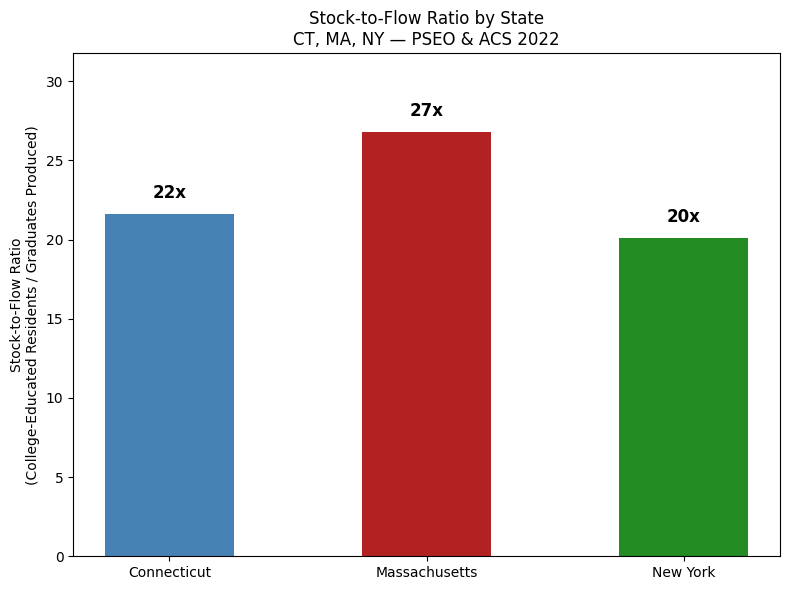

Figure 6 saved!


In [ ]:
# ---- Figure 6 revised: Stock-to-Flow Ratio by State (Clean Version) ----
ct_ratio = ct_stock * 1000 / ct_recent
ma_ratio = ma_stock * 1000 / ma_recent
ny_ratio = ny_stock * 1000 / ny_recent

states = ["Connecticut", "Massachusetts", "New York"]
ratios = [ct_ratio, ma_ratio, ny_ratio]
colors = ["steelblue", "firebrick", "forestgreen"]

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(states, ratios, color=colors, width=0.5)

ax.set_ylabel("Stock-to-Flow Ratio\n(College-Educated Residents / Graduates Produced)")
ax.set_title("Stock-to-Flow Ratio by State\nCT, MA, NY — PSEO & ACS 2022")

for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{ratio:.0f}x", ha="center", fontsize=12, fontweight="bold")

# Expands the y-axis to give the 27x label headroom
ax.set_ylim(0, max(ratios) + 5)

plt.tight_layout()
plt.savefig("fig6_stock_flow_ratio.png", dpi=150)
plt.show()
print("Figure 6 saved!")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import io
import numpy as np

API_KEY = "84be3d1f35c778150bb57bc7f815f88136459eac"

# Reload PSEO
pseo_df = pd.read_csv(io.BytesIO(requests.get(
    "https://lehd.ces.census.gov/data/pseo/R2024Q4/ct/pseoe_ct.csv.gz"
).content), compression="gzip", low_memory=False)

print("PSEO loaded:", pseo_df.shape)
print(pseo_df.columns.tolist())

PSEO loaded: (17888, 36)
['agg_level_pseo', 'inst_level', 'institution', 'degree_level', 'cip_level', 'cipcode', 'grad_cohort', 'grad_cohort_years', 'geo_level', 'geography', 'ind_level', 'industry', 'y1_p25_earnings', 'y1_p50_earnings', 'y1_p75_earnings', 'y1_grads_earn', 'y5_p25_earnings', 'y5_p50_earnings', 'y5_p75_earnings', 'y5_grads_earn', 'y10_p25_earnings', 'y10_p50_earnings', 'y10_p75_earnings', 'y10_grads_earn', 'y1_ipeds_count', 'y5_ipeds_count', 'y10_ipeds_count', 'status_y1_earnings', 'status_y1_grads_earn', 'status_y5_earnings', 'status_y5_grads_earn', 'status_y10_earnings', 'status_y10_grads_earn', 'status_y1_ipeds_count', 'status_y5_ipeds_count', 'status_y10_ipeds_count']


In [3]:
# Check what geography/employment location columns exist in PSEO
print(pseo_df.columns.tolist())
print(pseo_df[pseo_df["degree_level"] == 5].head(3))

['agg_level_pseo', 'inst_level', 'institution', 'degree_level', 'cip_level', 'cipcode', 'grad_cohort', 'grad_cohort_years', 'geo_level', 'geography', 'ind_level', 'industry', 'y1_p25_earnings', 'y1_p50_earnings', 'y1_p75_earnings', 'y1_grads_earn', 'y5_p25_earnings', 'y5_p50_earnings', 'y5_p75_earnings', 'y5_grads_earn', 'y10_p25_earnings', 'y10_p50_earnings', 'y10_p75_earnings', 'y10_grads_earn', 'y1_ipeds_count', 'y5_ipeds_count', 'y10_ipeds_count', 'status_y1_earnings', 'status_y1_grads_earn', 'status_y5_earnings', 'status_y5_grads_earn', 'status_y10_earnings', 'status_y10_grads_earn', 'status_y1_ipeds_count', 'status_y5_ipeds_count', 'status_y10_ipeds_count']
    agg_level_pseo inst_level  institution  degree_level cip_level  cipcode  \
4               26          S            9             5         A      0.0   
10              28          S            9             5         2      1.0   
16              28          S            9             5         2      3.0   

    grad_co

In [4]:
# Load the PSEO flows file - this shows where CT graduates actually work
pseo_flows = pd.read_csv(io.BytesIO(requests.get(
    "https://lehd.ces.census.gov/data/pseo/R2024Q4/ct/pseof_ct.csv.gz"
).content), compression="gzip", low_memory=False)

print("Flows shape:", pseo_flows.shape)
print("Columns:", pseo_flows.columns.tolist())
print(pseo_flows.head(3))

Flows shape: (1248030, 30)
Columns: ['agg_level_pseo', 'inst_level', 'institution', 'degree_level', 'cip_level', 'cipcode', 'grad_cohort', 'grad_cohort_years', 'geo_level', 'geography', 'ind_level', 'industry', 'y1_grads_emp', 'y1_grads_emp_instate', 'y5_grads_emp', 'y5_grads_emp_instate', 'y10_grads_emp', 'y10_grads_emp_instate', 'y1_grads_nme', 'y5_grads_nme', 'y10_grads_nme', 'status_y1_grads_emp', 'status_y1_grads_emp_instate', 'status_y5_grads_emp', 'status_y5_grads_emp_instate', 'status_y10_grads_emp', 'status_y10_grads_emp_instate', 'status_y1_grads_nme', 'status_y5_grads_nme', 'status_y10_grads_nme']
   agg_level_pseo inst_level  institution  degree_level cip_level  cipcode  \
0              26          S            9             1         A        0   
1              26          S            9             2         A        0   
2              26          S            9             3         A        0   

   grad_cohort  grad_cohort_years geo_level  geography  ... y10_grads_n

In [5]:
# Filter to bachelor's, institution-level aggregate, all cohorts combined
flows_bach = pseo_flows[
    (pseo_flows["degree_level"] == 5) &
    (pseo_flows["agg_level_pseo"] == 26) &
    (pseo_flows["grad_cohort"] == 0) &
    (pseo_flows["ind_level"] == "A") &
    (pseo_flows["cip_level"] == "A")
].copy()

print("Rows:", flows_bach.shape[0])
print(flows_bach[["institution","y1_grads_emp","y1_grads_emp_instate",
                   "y5_grads_emp","y5_grads_emp_instate",
                   "y10_grads_emp","y10_grads_emp_instate"]].head(10))

Rows: 1
   institution  y1_grads_emp  y1_grads_emp_instate  y5_grads_emp  \
4            9      180692.0              123353.0      121049.0   

   y5_grads_emp_instate  y10_grads_emp  y10_grads_emp_instate  
4               74340.0        78633.0                47409.0  


In [6]:
# Load MA and NY flows files
ma_flows = pd.read_csv(io.BytesIO(requests.get(
    "https://lehd.ces.census.gov/data/pseo/R2024Q4/ma/pseof_ma.csv.gz"
).content), compression="gzip", low_memory=False)

ny_flows = pd.read_csv(io.BytesIO(requests.get(
    "https://lehd.ces.census.gov/data/pseo/R2024Q4/ny/pseof_ny.csv.gz"
).content), compression="gzip", low_memory=False)

def get_retention(df):
    row = df[
        (df["degree_level"] == 5) &
        (df["agg_level_pseo"] == 26) &
        (df["grad_cohort"] == 0) &
        (df["ind_level"] == "A") &
        (df["cip_level"] == "A")
    ]
    return row[["institution","y1_grads_emp","y1_grads_emp_instate",
                "y5_grads_emp","y5_grads_emp_instate",
                "y10_grads_emp","y10_grads_emp_instate"]]

print("MA:", get_retention(ma_flows))
print("NY:", get_retention(ny_flows))

MA:    institution  y1_grads_emp  y1_grads_emp_instate  y5_grads_emp  \
4           25      131675.0              104823.0       89536.0   

   y5_grads_emp_instate  y10_grads_emp  y10_grads_emp_instate  
4               66826.0        41517.0                29202.0  
NY:    institution  y1_grads_emp  y1_grads_emp_instate  y5_grads_emp  \
3           36      723855.0              616748.0      530252.0   

   y5_grads_emp_instate  y10_grads_emp  y10_grads_emp_instate  
3              420192.0       394818.0               294310.0  


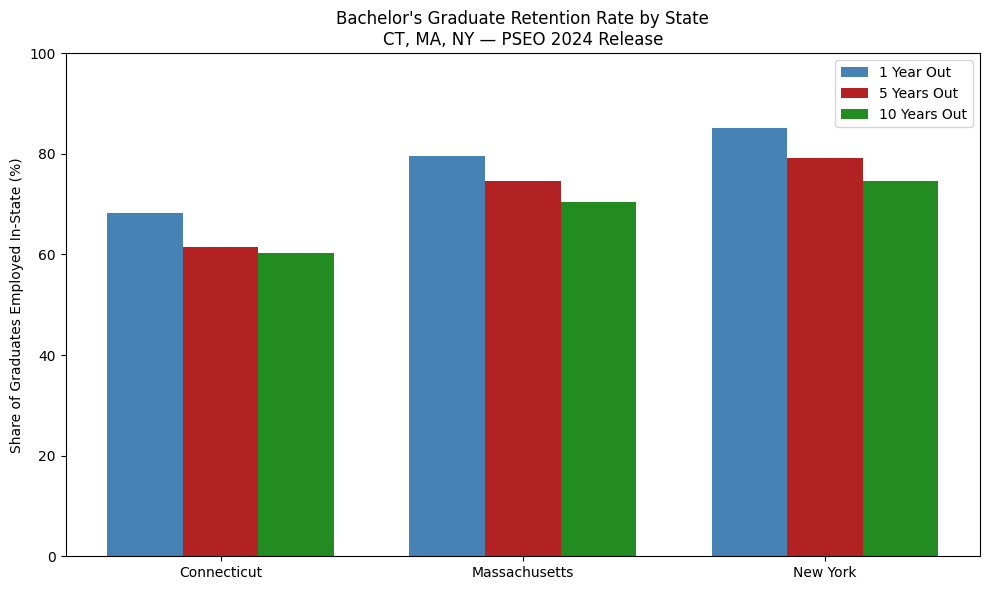

Figure 6 saved!


In [7]:
# ---- Figure 6 (revised): Graduate Retention Rates CT vs MA vs NY ----
states = ["Connecticut", "Massachusetts", "New York"]

y1_rates = [
    123353 / 180692 * 100,
    104823 / 131675 * 100,
    616748 / 723855 * 100
]
y5_rates = [
    74340 / 121049 * 100,
    66826 / 89536  * 100,
    420192 / 530252 * 100
]
y10_rates = [
    47409 / 78633  * 100,
    29202 / 41517  * 100,
    294310 / 394818 * 100
]

x = range(len(states))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar([i - 0.25 for i in x], y1_rates,  width, label="1 Year Out",  color="steelblue")
ax.bar([i        for i in x], y5_rates,  width, label="5 Years Out", color="firebrick")
ax.bar([i + 0.25 for i in x], y10_rates, width, label="10 Years Out",color="forestgreen")

ax.set_xticks(list(x))
ax.set_xticklabels(states)
ax.set_ylabel("Share of Graduates Employed In-State (%)")
ax.set_title("Bachelor's Graduate Retention Rate by State\nCT, MA, NY — PSEO 2024 Release")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig("fig6_retention_rates.png", dpi=150)
plt.show()
print("Figure 6 saved!")

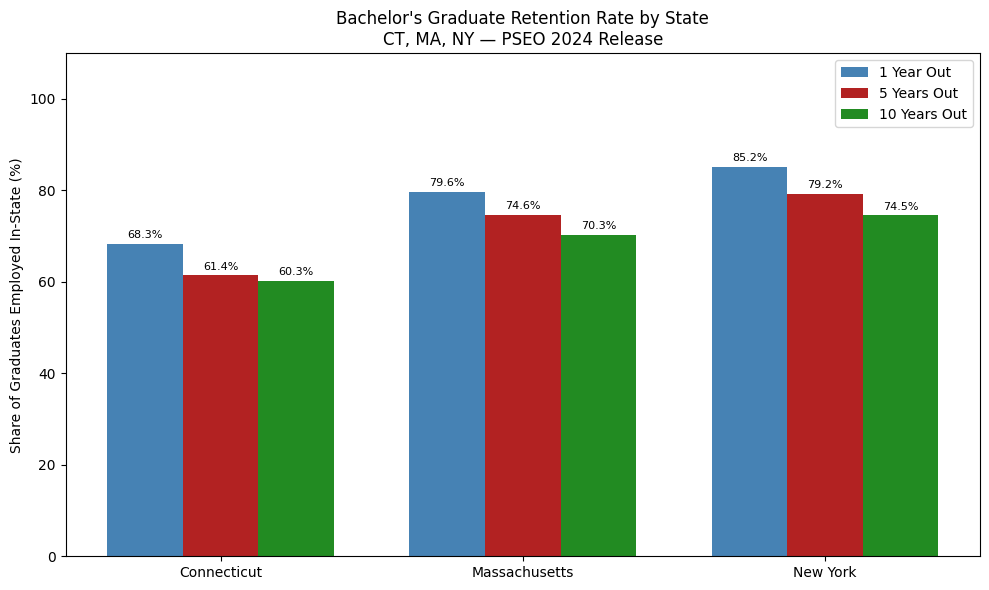

Figure 6 saved!


In [8]:
# ---- Figure 6 (revised): Graduate Retention Rates CT vs MA vs NY ----
states = ["Connecticut", "Massachusetts", "New York"]

y1_rates = [
    123353 / 180692 * 100,
    104823 / 131675 * 100,
    616748 / 723855 * 100
]
y5_rates = [
    74340 / 121049 * 100,
    66826 / 89536  * 100,
    420192 / 530252 * 100
]
y10_rates = [
    47409 / 78633  * 100,
    29202 / 41517  * 100,
    294310 / 394818 * 100
]

x = range(len(states))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - 0.25 for i in x], y1_rates,  width, label="1 Year Out",  color="steelblue")
bars2 = ax.bar([i        for i in x], y5_rates,  width, label="5 Years Out", color="firebrick")
bars3 = ax.bar([i + 0.25 for i in x], y10_rates, width, label="10 Years Out",color="forestgreen")

# Add percentage labels on each bar
for bar in bars1 + bars2 + bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(states)
ax.set_ylabel("Share of Graduates Employed In-State (%)")
ax.set_title("Bachelor's Graduate Retention Rate by State\nCT, MA, NY — PSEO 2024 Release")
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.savefig("fig6_retention_rates.png", dpi=150)
plt.show()
print("Figure 6 saved!")

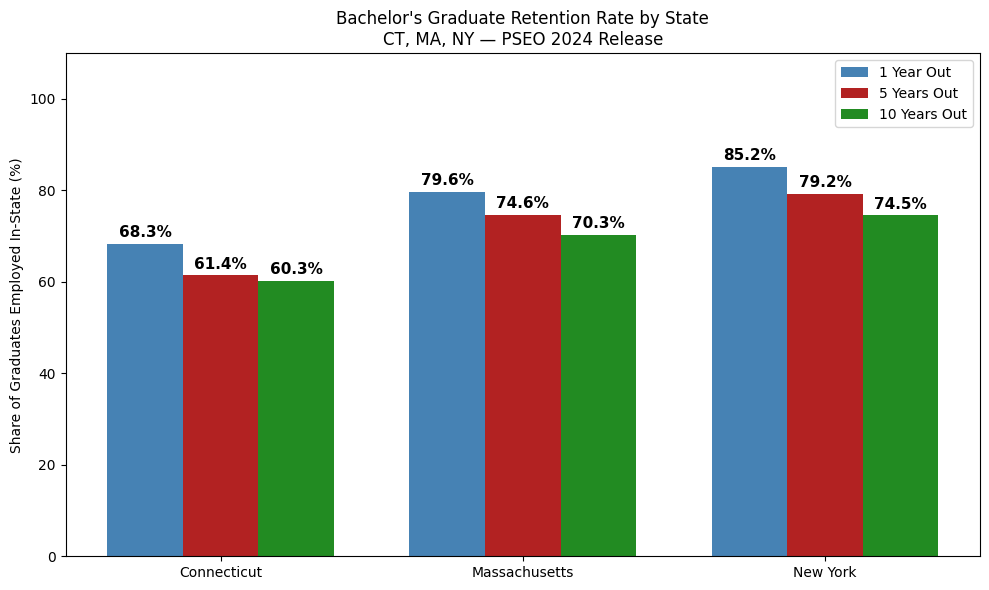

Figure 6 saved!


In [9]:
# ---- Figure 6 (revised): Graduate Retention Rates CT vs MA vs NY ----
states = ["Connecticut", "Massachusetts", "New York"]

y1_rates = [
    123353 / 180692 * 100,
    104823 / 131675 * 100,
    616748 / 723855 * 100
]
y5_rates = [
    74340 / 121049 * 100,
    66826 / 89536  * 100,
    420192 / 530252 * 100
]
y10_rates = [
    47409 / 78633  * 100,
    29202 / 41517  * 100,
    294310 / 394818 * 100
]

x = range(len(states))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - 0.25 for i in x], y1_rates,  width, label="1 Year Out",  color="steelblue")
bars2 = ax.bar([i        for i in x], y5_rates,  width, label="5 Years Out", color="firebrick")
bars3 = ax.bar([i + 0.25 for i in x], y10_rates, width, label="10 Years Out",color="forestgreen")

# Add percentage labels on each bar
for bar in bars1 + bars2 + bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(states)
ax.set_ylabel("Share of Graduates Employed In-State (%)")
ax.set_title("Bachelor's Graduate Retention Rate by State\nCT, MA, NY — PSEO 2024 Release")
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.savefig("fig6_retention_rates.png", dpi=150)
plt.show()
print("Figure 6 saved!")